In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.io

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

np.random.seed(42)

## Actividad 1
El archivo `data_1.txt` contiene un conjunto sencillo para regresión lineal. La primera columna corresponde a la variable independiente y la segunda a la variable objetivo.

Los datos representan el precio de una vivienda en función de la población de una ciudad. La población está expresada en unidades de 10.000 habitantes y el precio en unidades de 10.000 dólares.

1. Cargue los datos y represéntelos mediante un diagrama de dispersión.
2. Ajuste un modelo `LinearRegression`.
3. Obtenga y muestre el término independiente y la pendiente.
4. Obtenga y muestre los parámetros del modelo.
5. Grafique la recta ajustada sobre los datos.
6. Interprete el signo y la magnitud de la pendiente.


In [3]:
df_data1 = pd.read_csv("./data_1.txt", header=None, sep = ",")
df_data1.head()

,0,1
0,6.1101,17.5920
1,5.5277,9.1302
2,8.5186,13.6620
3,7.0032,11.8540
4,5.8598,6.8233


<Axes: title={'center': 'Data 1 plot'}, xlabel='0', ylabel='1'>

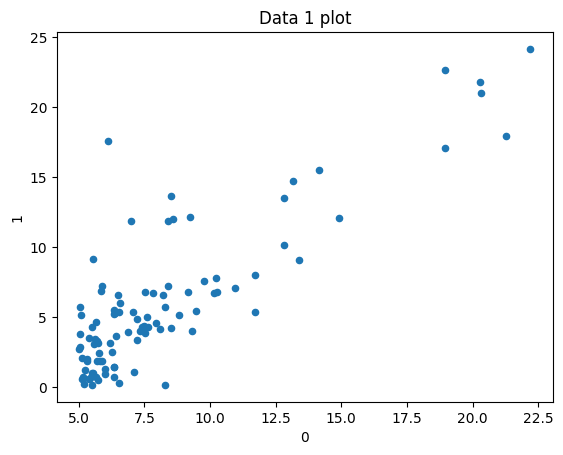

In [4]:
df_data1.plot(kind="scatter", x = 0, y = 1, title = "Data 1 plot")

In [7]:
x = df_data1[[0]]
y = df_data1[1]
modelo_lin = LinearRegression()
modelo_lin.fit(x, y)
y_pred = modelo_lin.predict(x)
print ('Variable independiente: ', modelo_lin.coef_[0])
print ('Variable dependiente: ', modelo_lin.intercept_)
print ('Parametros del modelo: ', modelo_lin.coef_[0], modelo_lin.intercept_)

Variable independiente:  1.1697762389135078
Variable dependiente:  -3.5809620099565436
Parametros del modelo:  1.1697762389135078 -3.5809620099565436


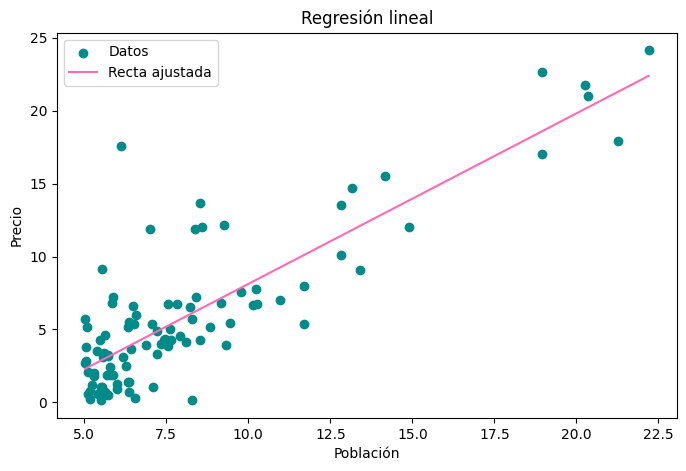

In [8]:
orden = np.argsort(x[0].to_numpy())

plt.figure(figsize=(8, 5))
plt.scatter(x[0], y, label="Datos", color="darkcyan")
plt.plot(
    x[0].to_numpy()[orden],
    y_pred[orden],
    color="hotpink",
    label="Recta ajustada"
)

plt.xlabel("Población")
plt.ylabel("Precio")
plt.title("Regresión lineal")
plt.legend()
plt.show()

## Actividad 2

Para analizar desempeño sobre datos no utilizados durante el ajuste, dividiremos `data_2.csv` en un conjunto de entrenamiento y otro de prueba.

1. Separe los datos en entrenamiento y prueba.
2. Ajuste `LinearRegression` usando únicamente el conjunto de entrenamiento.
3. Calcule MSE, RMSE y $R^2$ en ambos conjuntos.
4. Compare los errores y discuta si existe evidencia de un problema de generalización.

In [9]:
df_data2 = pd.read_csv("./data_2.csv", header=None, sep=",", skiprows=1)
df_data2.head()

,0,1
0,9.243561,20.798373
1,5.352573,14.425295
2,9.825191,27.804927
3,2.191246,10.313729
4,6.060049,17.087840


In [10]:
train_set, test_set = train_test_split(df_data2, test_size = 0.2, random_state = 42)
train_labels = train_set.pop(1)

In [11]:
modelo_lin.fit(train_set, train_labels)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[2.37]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.701
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[1826.03]


In [12]:
df_predictions = modelo_lin.predict(train_set)
df_predictions[:5].round() #hacemos una prediccion

array([22., 24., 11., 18., 16.])

In [ ]:
mean_squared_error(train_labels, df_predictions)
root_mean_squared_error(train_labels, df_predictions)
r2_score(train_labels, df_predictions)
# dice de ambos conjuntos calcular pero no se si se refiere a train y test o que

0.915387859825229

## Actividad 3

1. Represente los datos.
2. Ajuste modelos polinomiales de grados 1, 3, 7 y 13.
3. Grafique las curvas sobre el mismo conjunto de datos.
4. Compare cómo cambia la forma de la función al aumentar el grado.
5. ¿Puede decidir cuál generaliza mejor mirando únicamente este gráfico? Justifique.

<Axes: title={'center': 'Representación de los datos'}, xlabel='0', ylabel='1'>

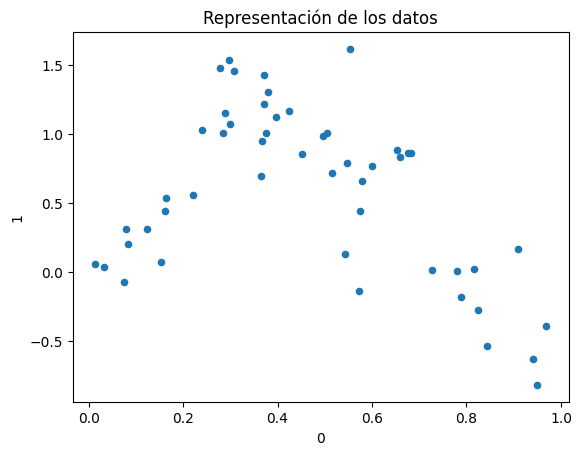

In [21]:
df_data3 = pd.read_csv("./data_3.csv", header=None, sep=",", skiprows=1)

df_data3.plot(kind="scatter", x = 0, y = 1, title = "Representación de los datos")

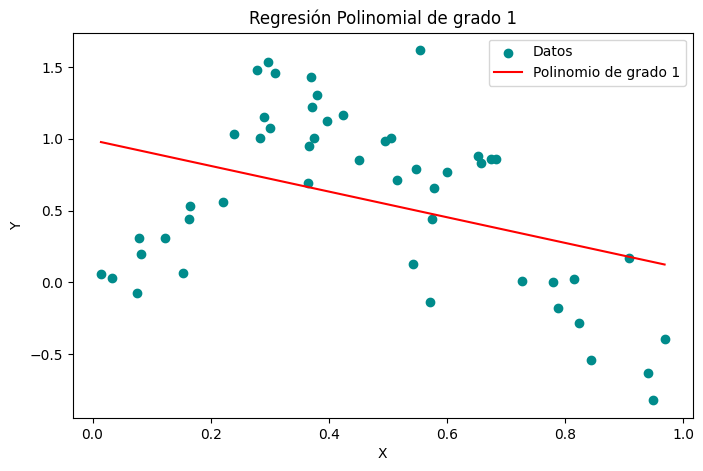

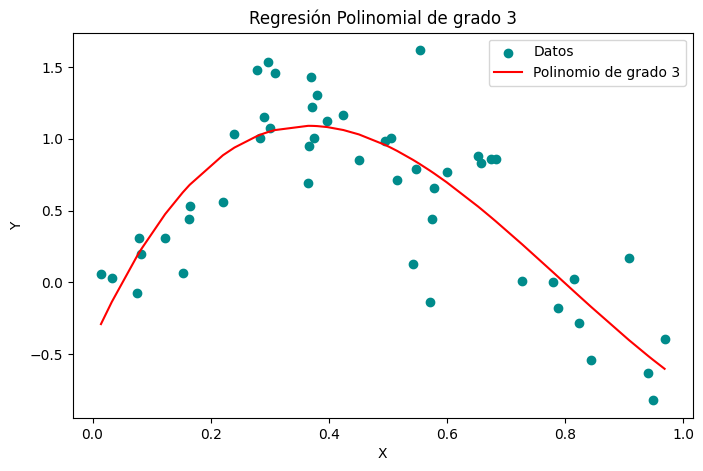

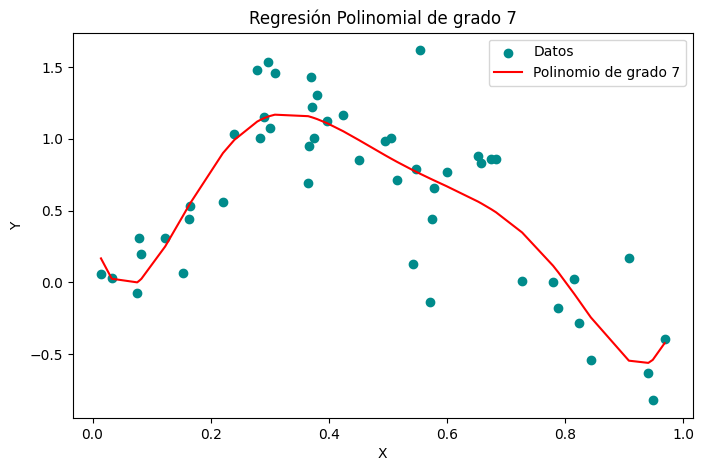

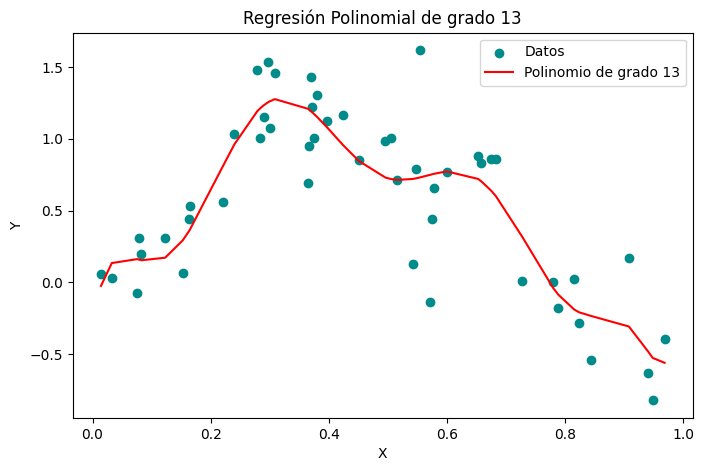

In [ ]:
#Ajustamos un modelo de regresión polinomial para distintos grados y graficamos los resultados
for grado in [1, 3, 7, 13]:
    poly = PolynomialFeatures(degree=grado)
    X_poly = poly.fit_transform(df_data3[[0]])   

    modelo = LinearRegression()
    modelo.fit(X_poly, df_data3[1])
    y_pred = modelo.predict(X_poly)

    plt.figure(figsize=(8, 5))
    plt.scatter(df_data3[0], df_data3[1], label="Datos", color="darkcyan")
    plt.plot(df_data3[0], y_pred, label=f"Polinomio de grado {grado}", color="red")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.title(f"Regresión Polinomial de grado {grado}")
    plt.legend()
    plt.show()


Como se observa en las gráficas, a medida que aumenta el grado del polinomio, el **ajuste** a los datos de entrenamiento se vuelve cada vez más preciso, llegando incluso a ser **casi perfecto en los grados más altos** (como el 13). Sin embargo, eso es un claro indicio de sobreajuste (overfitting) ya que el polinomio comienza a modelar el ruido propio de los datos en lugar de la tendencia real subyacente.

Por este motivo, resulta conveniente **seleccionar un grado de polinomio** que logre **capturar la tendencia real** de los datos sin ajustarse al ruido, buscando un equilibrio adecuado entre sesgo y varianza. Un modelo con demasiado sesgo (grado muy bajo) puede no captar relaciones existentes en los datos, mientras que uno con demasiada varianza (grado muy alto) generaliza mal ante datos nuevos. Considerando esto, creemos conveniente que el **grado 3 constituye la mejor opción** para el modelo polinomial, ya que mantiene un buen ajuste sin incurrir en sobreajuste.